<a href="https://colab.research.google.com/github/KhalPrawira/Big-Data_Assignment/blob/main/Code/UTS/Revisi(Binning)_Kelompok11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install openmeteo-requests

In [2]:
pip install requests-cache retry-requests numpy pandas

##Filter & Fetch Data Streaming

In [3]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

url = "https://air-quality-api.open-meteo.com/v1/air-quality"

locations = [
    {"name": "Ambon City", "latitude": -3.6958,      "longitude": 128.1833},
    {"name": "Bali", "latitude": -8.3333, "longitude": 115},
    {"name": "Balikpapan", "latitude": -1.2674, "longitude": 116.8310},
    {"name": "Bandung", "latitude": -6.9222, "longitude": 107.6069},
    {"name": "Banda Aceh", "latitude": 5.5417,  "longitude": 95.3333},
    {"name": "Bekasi", "latitude": -6.2349, "longitude": 106.9896},
    {"name": "Gorontalo", "latitude": 0.5375,  "longitude": 123.0625},
    {"name": "Jakarta", "latitude": -6.2088, "longitude": 106.8456},
    {"name": "Jayapura", "latitude": -2.5337,   "longitude": 140.7181},
    {"name": "Jogja", "latitude": -3.4292, "longitude": 119.222},
    {"name": "Kendari", "latitude": -3.9778,   "longitude": 122.5151},
    {"name": "Kupang", "latitude": -10.1708,    "longitude": 123.6069},
    {"name": "Makassar", "latitude": 0.9039, "longitude": 122.7586},
    {"name": "Manado", "latitude": 1.4822,      "longitude": 124.8489},
    {"name": "Mataram", "latitude": -8.5833,   "longitude": 116.1167},
    {"name": "Medan", "latitude": 3.5833, "longitude": 98.6667},
    {"name": "Merauke", "latitude": -8.4996,     "longitude": 140.4061},
    {"name": "Padang", "latitude": -0.9492, "longitude": 100.3543},
    {"name": "Palangkaraya", "latitude": -2.2083,"longitude": 113.9165},
    {"name": "Palembang", "latitude": -2.9167, "longitude": 104.7458},
    {"name": "Palu", "latitude": -0.9083,       "longitude": 119.8708},
    {"name": "Pekanbaru", "latitude": 0.5167, "longitude": 101.4417},
    {"name": "Pontianak", "latitude": -0.0319,   "longitude": 109.325},
    {"name": "Samarinda", "latitude": -0.4917,   "longitude": 117.1458},
    {"name": "Semarang", "latitude": -6.9931, "longitude": 110.4208},
    {"name": "Surabaya", "latitude": -7.2575, "longitude": 112.7521},
    {"name": "Tarakan", "latitude": 3.3133,      "longitude": 117.5915},
    {"name": "Tegal", "latitude": -6.8694, "longitude": 109.1402},
    {"name": "Ternate", "latitude": 0.7906,      "longitude": 127.3842},
    {"name": "Wonosobo", "latitude": -7.3589, "longitude": 109.9031}
]

all_hourly_dataframes = []

for location in locations:
    print(f"Fetching data for {location['name']}...")
    params = {
        "latitude": location["latitude"],
        "longitude": location["longitude"],
        "hourly": ["us_aqi", "us_aqi_pm2_5", "us_aqi_nitrogen_dioxide", "us_aqi_carbon_monoxide", "us_aqi_ozone", "us_aqi_pm10", "us_aqi_sulphur_dioxide"],
        "timezone": "auto",
        "start_date": "2025-09-10",
        "end_date": "2025-10-10",
    }
    responses = openmeteo.weather_api(url, params=params)

    response = responses[0]
    print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
    print(f"Elevation: {response.Elevation()} m asl")
    print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
    print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

    hourly = response.Hourly()
    hourly_us_aqi = hourly.Variables(0).ValuesAsNumpy()
    hourly_us_aqi_pm2_5 = hourly.Variables(1).ValuesAsNumpy()
    hourly_us_aqi_nitrogen_dioxide = hourly.Variables(2).ValuesAsNumpy()
    hourly_us_aqi_carbon_monoxide = hourly.Variables(3).ValuesAsNumpy()
    hourly_us_aqi_ozone = hourly.Variables(4).ValuesAsNumpy()
    hourly_us_aqi_pm10 = hourly.Variables(5).ValuesAsNumpy()
    hourly_us_aqi_sulphur_dioxide = hourly.Variables(6).ValuesAsNumpy()

    hourly_data = {
        "date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
        )
    }

    hourly_data["us_aqi"] = hourly_us_aqi
    hourly_data["us_aqi_pm2_5"] = hourly_us_aqi_pm2_5
    hourly_data["us_aqi_nitrogen_dioxide"] = hourly_us_aqi_nitrogen_dioxide
    hourly_data["us_aqi_carbon_monoxide"] = hourly_us_aqi_carbon_monoxide
    hourly_data["us_aqi_ozone"] = hourly_us_aqi_ozone
    hourly_data["us_aqi_pm10"] = hourly_us_aqi_pm10
    hourly_data["us_aqi_sulphur_dioxide"] = hourly_us_aqi_sulphur_dioxide

    hourly_dataframe_single_location = pd.DataFrame(data = hourly_data)
    hourly_dataframe_single_location['location_name'] = location['name']
    all_hourly_dataframes.append(hourly_dataframe_single_location)

overall_hourly_dataframe = pd.concat(all_hourly_dataframes, ignore_index=True)
print("\nOverall Hourly Data for all locations:\n")
display(overall_hourly_dataframe.head())
display(overall_hourly_dataframe.tail())

Fetching data for Ambon City...
Coordinates: -3.6999969482421875°N 128.20001220703125°E
Elevation: 7.0 m asl
Timezone: b'Asia/Jayapura'b'GMT+9'
Timezone difference to GMT+0: 32400s
Fetching data for Bali...
Coordinates: -8.299995422363281°N 115.0°E
Elevation: 616.0 m asl
Timezone: b'Asia/Makassar'b'GMT+8'
Timezone difference to GMT+0: 28800s
Fetching data for Balikpapan...
Coordinates: -1.2999954223632812°N 116.80001831054688°E
Elevation: 50.0 m asl
Timezone: b'Asia/Makassar'b'GMT+8'
Timezone difference to GMT+0: 28800s
Fetching data for Bandung...
Coordinates: -6.900001525878906°N 107.60000610351562°E
Elevation: 707.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezone difference to GMT+0: 25200s
Fetching data for Banda Aceh...
Coordinates: 5.5°N 95.30001831054688°E
Elevation: 5.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezone difference to GMT+0: 25200s
Fetching data for Bekasi...
Coordinates: -6.1999969482421875°N 107.0°E
Elevation: 19.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezo

,date,us_aqi,us_aqi_pm2_5,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_pm10,us_aqi_sulphur_dioxide,location_name
0,2025-09-09 15:00:00+00:00,15.596010,11.458334,0.591017,5.560386,15.596010,3.087121,0.218103,Ambon City
1,2025-09-09 16:00:00+00:00,15.132191,11.354167,0.492514,6.044686,15.132191,3.075758,0.218103,Ambon City
2,2025-09-09 17:00:00+00:00,14.726344,11.267361,0.443262,6.349034,14.726344,3.071970,0.163577,Ambon City
3,2025-09-09 18:00:00+00:00,14.436457,11.180555,0.344760,6.411836,14.436457,3.068182,0.163577,Ambon City
4,2025-09-09 19:00:00+00:00,14.320501,11.076390,0.295508,6.138889,14.320501,3.064394,0.163577,Ambon City


,date,us_aqi,us_aqi_pm2_5,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_pm10,us_aqi_sulphur_dioxide,location_name
22315,2025-10-10 12:00:00+00:00,156.024124,156.024124,7.978724,2.729469,85.416664,56.758331,3.162487,Wonosobo
22316,2025-10-10 13:00:00+00:00,155.186401,155.186401,8.224981,3.483092,75.000000,55.933338,2.998909,Wonosobo
22317,2025-10-10 14:00:00+00:00,153.921051,153.921051,8.618992,4.439614,61.819725,54.695839,2.726282,Wonosobo
22318,2025-10-10 15:00:00+00:00,151.925430,151.925430,9.013002,5.577294,48.875229,52.766670,2.399128,Wonosobo
22319,2025-10-10 16:00:00+00:00,149.447891,149.447891,9.259259,6.822464,43.773190,50.785416,1.853872,Wonosobo


##Menyesuaikan Nama Fitur Data Streaming dengan Dataset Batch

In [4]:
import numpy as np

air_quality_data = pd.DataFrame({
    'Date': overall_hourly_dataframe['date'],
    'City': overall_hourly_dataframe['location_name'],
    'CO': overall_hourly_dataframe['us_aqi_carbon_monoxide'],
    'CO2': np.nan,
    'NO2': overall_hourly_dataframe['us_aqi_nitrogen_dioxide'],
    'SO2': overall_hourly_dataframe['us_aqi_sulphur_dioxide'],
    'O3': overall_hourly_dataframe['us_aqi_ozone'],
    'PM2.5': overall_hourly_dataframe['us_aqi_pm2_5'],
    'PM10': overall_hourly_dataframe['us_aqi_pm10'],
    'AQI': overall_hourly_dataframe['us_aqi']
})

print("Restructured Air Quality Data:")
display(air_quality_data.head())
display(air_quality_data.tail())

Restructured Air Quality Data:


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-09-09 15:00:00+00:00,Ambon City,5.560386,NaN,0.591017,0.218103,15.596010,11.458334,3.087121,15.596010
1,2025-09-09 16:00:00+00:00,Ambon City,6.044686,NaN,0.492514,0.218103,15.132191,11.354167,3.075758,15.132191
2,2025-09-09 17:00:00+00:00,Ambon City,6.349034,NaN,0.443262,0.163577,14.726344,11.267361,3.071970,14.726344
3,2025-09-09 18:00:00+00:00,Ambon City,6.411836,NaN,0.344760,0.163577,14.436457,11.180555,3.068182,14.436457
4,2025-09-09 19:00:00+00:00,Ambon City,6.138889,NaN,0.295508,0.163577,14.320501,11.076390,3.064394,14.320501


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
22315,2025-10-10 12:00:00+00:00,Wonosobo,2.729469,NaN,7.978724,3.162487,85.416664,156.024124,56.758331,156.024124
22316,2025-10-10 13:00:00+00:00,Wonosobo,3.483092,NaN,8.224981,2.998909,75.000000,155.186401,55.933338,155.186401
22317,2025-10-10 14:00:00+00:00,Wonosobo,4.439614,NaN,8.618992,2.726282,61.819725,153.921051,54.695839,153.921051
22318,2025-10-10 15:00:00+00:00,Wonosobo,5.577294,NaN,9.013002,2.399128,48.875229,151.925430,52.766670,151.925430
22319,2025-10-10 16:00:00+00:00,Wonosobo,6.822464,NaN,9.259259,1.853872,43.773190,149.447891,50.785416,149.447891


In [5]:
air_quality_data.to_csv('air_quality_data(fetch).csv', index=False)
print("Dataset telah berhasil disimpan")

Dataset telah berhasil disimpan


##Combine Data Streaming dengan Data Batch

In [6]:
data1 = "https://github.com/KhalPrawira/Big-Data_Assignment/raw/refs/heads/main/Dataset/Air_Quality.csv"

data2 = "/content/air_quality_data(fetch).csv"

df1 = pd.read_csv(data1)

df2 = pd.read_csv(data2)

combined_df = pd.concat([df1, df2], ignore_index=True)

print("Dataframe pertama (df1) head:")
print(df1.head())
print("\nDataframe kedua (df2) head:")
print(df2.head())
print("\nGabungan Dataframe (combined_df) head:")
print(combined_df.head())

print(f"\nJumlah baris df1: {len(df1)}")
print(f"Jumlah baris df2: {len(df2)}")
print(f"Jumlah baris gabungan: {len(combined_df)}")

Dataframe pertama (df1) head:
                        Date      City     CO  CO2   NO2  SO2    O3  PM2.5  \
0  2024-01-01 00:00:00+00:00  Brasilia  323.0  NaN  23.8  2.8  42.0   12.0   
1  2024-01-01 01:00:00+00:00  Brasilia  318.0  NaN  21.9  2.7  40.0   12.5   
2  2024-01-01 02:00:00+00:00  Brasilia  309.0  NaN  19.2  2.6  39.0   12.1   
3  2024-01-01 03:00:00+00:00  Brasilia  295.0  NaN  16.3  2.4  38.0   11.4   
4  2024-01-01 04:00:00+00:00  Brasilia  270.0  NaN  13.0  2.1  40.0   10.2   

   PM10        AQI  
0  17.1  16.800000  
1  17.9  16.000000  
2  17.3  15.599999  
3  16.2  15.200000  
4  14.6  16.000000  

Dataframe kedua (df2) head:
                        Date        City        CO  CO2       NO2       SO2  \
0  2025-09-09 15:00:00+00:00  Ambon City  5.560386  NaN  0.591017  0.218103   
1  2025-09-09 16:00:00+00:00  Ambon City  6.044686  NaN  0.492514  0.218103   
2  2025-09-09 17:00:00+00:00  Ambon City  6.349034  NaN  0.443262  0.163577   
3  2025-09-09 18:00:00+00:00  

##Simpan Gabungan Data

In [7]:
output_filename = "combined_air_quality_data.csv"
combined_df.to_csv(output_filename, index=False)
print(f"Dataset gabungan telah berhasil disimpan ke '{output_filename}'")

Dataset gabungan telah berhasil disimpan ke 'combined_air_quality_data.csv'


#Load & Explore

In [8]:
import pandas as pd
import numpy as np

df = "/content/combined_air_quality_data.csv"
df = pd.read_csv(df)

print("jumlah baris dan kolom: ", df.shape)
display(df.head())

jumlah baris dan kolom:  (75024, 10)


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


##Cek nilai kosong dan duplikasi

In [9]:
df.info()

print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nJumlah data duplikat:", duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75024 entries, 0 to 75023
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    75024 non-null  object 
 1   City    75024 non-null  object 
 2   CO      75024 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     75024 non-null  float64
 5   SO2     75024 non-null  float64
 6   O3      75024 non-null  float64
 7   PM2.5   75024 non-null  float64
 8   PM10    75024 non-null  float64
 9   AQI     75024 non-null  float64
dtypes: float64(8), object(2)
memory usage: 5.7+ MB

Jumlah missing value di setiap kolom:
Date         0
City         0
CO           0
CO2      65376
NO2          0
SO2          0
O3           0
PM2.5        0
PM10         0
AQI          0
dtype: int64

Jumlah data duplikat: 0


##Hapus CO2

In [10]:
df.drop('CO2', axis=1, inplace=True)
print("Kolom 'CO2' telah dihapus.")
df.info()

print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())

Kolom 'CO2' telah dihapus.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75024 entries, 0 to 75023
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    75024 non-null  object 
 1   City    75024 non-null  object 
 2   CO      75024 non-null  float64
 3   NO2     75024 non-null  float64
 4   SO2     75024 non-null  float64
 5   O3      75024 non-null  float64
 6   PM2.5   75024 non-null  float64
 7   PM10    75024 non-null  float64
 8   AQI     75024 non-null  float64
dtypes: float64(7), object(2)
memory usage: 5.2+ MB

Jumlah missing value di setiap kolom:
Date     0
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
AQI      0
dtype: int64


##Cek Outlier

In [11]:
print("\nMendeteksi Outlier menggunakan IQR:")

numerical_cols = df.select_dtypes(include=np.number).columns

outlier_count = 0
total_data_points = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mendeteksi outlier
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(col_outliers)
    outlier_count += num_outliers
    total_data_points += len(df[col])

    if num_outliers > 0:
        print(f"  Kolom '{col}': {num_outliers} outlier terdeteksi ({round((num_outliers / len(df[col])) * 100, 2)}% dari total data kolom ini)")
    else:
        print(f"  Kolom '{col}': Tidak ada outlier terdeteksi.")

print(f"\nTotal outlier terdeteksi di seluruh kolom numerik: {outlier_count} dari {total_data_points} data poin.")
if total_data_points > 0:
    print(f"Persentase total outlier: {round((outlier_count / total_data_points) * 100, 2)}%")
else:
    print("Tidak ada data poin untuk dianalisis.")


Mendeteksi Outlier menggunakan IQR:
  Kolom 'CO': 1969 outlier terdeteksi (2.62% dari total data kolom ini)
  Kolom 'NO2': 2680 outlier terdeteksi (3.57% dari total data kolom ini)
  Kolom 'SO2': 6397 outlier terdeteksi (8.53% dari total data kolom ini)
  Kolom 'O3': 2540 outlier terdeteksi (3.39% dari total data kolom ini)
  Kolom 'PM2.5': 4314 outlier terdeteksi (5.75% dari total data kolom ini)
  Kolom 'PM10': 7778 outlier terdeteksi (10.37% dari total data kolom ini)
  Kolom 'AQI': 4771 outlier terdeteksi (6.36% dari total data kolom ini)

Total outlier terdeteksi di seluruh kolom numerik: 30449 dari 525168 data poin.
Persentase total outlier: 5.8%


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import requests
import time

##Binning AQI menjadi Kategori EPA

In [13]:
def categorize_aqi_num(aqi):
    if 0 <= aqi <= 50:
        return 0
    elif 51 <= aqi <= 100:
        return 1
    elif 101 <= aqi <= 150:
        return 2
    elif 151 <= aqi <= 200:
        return 3
    elif 201 <= aqi <= 300:
        return 4
    elif 301 <= aqi <= 500:
        return 5
    else:
        return 6  # optional: di luar skala

df['AQI_Label'] = df['AQI'].apply(categorize_aqi_num)
print("Distribusi label awal:")
print(df['AQI_Label'].value_counts())

Distribusi label awal:
AQI_Label
0    46188
1    21165
2     3216
3     3024
6     1152
4      279
Name: count, dtype: int64


##Spli Data & Scaling

In [14]:
X1 = df[['NO2', 'SO2', 'O3', 'PM2.5', 'PM10']]
y1 = df['AQI_Label']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X1_train)
X1_test_scaled = scaler.transform(X1_test)

##Menangani Data Tidak Seimbang

In [15]:
sm = SMOTE(random_state=42)
X1_train_bal, y1_train_bal = sm.fit_resample(X1_train_scaled, y1_train)

print("\nDistribusi label setelah SMOTE:")
print(pd.Series(y1_train_bal).value_counts())


Distribusi label setelah SMOTE:
AQI_Label
1    36950
0    36950
2    36950
6    36950
3    36950
4    36950
Name: count, dtype: int64


##Inisialisasi dan Training Model

In [16]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced_subsample'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced'),
    "KNN": KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X1_train_bal, y1_train_bal)
    y_pred = model.predict(X1_test_scaled)
    acc = accuracy_score(y1_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy']).sort_values(by='Accuracy', ascending=False)
print("\n=== Hasil Akurasi Tiap Model ===")
print(results_df)

Random Forest Accuracy: 0.9345
Decision Tree Accuracy: 0.9019
Logistic Regression Accuracy: 0.7396
KNN Accuracy: 0.8914

=== Hasil Akurasi Tiap Model ===
                     Accuracy
Random Forest        0.934489
Decision Tree        0.901899
KNN                  0.891436
Logistic Regression  0.739553


##Evaluasi Model Terbaik

In [19]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"\nModel terbaik: {best_model_name}")

y_best_pred = best_model.predict(X1_test_scaled)

print("\n=== Classification Report ===")
print(classification_report(y1_test, y_best_pred))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y1_test, y_best_pred))


Model terbaik: Random Forest

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      9238
           1       0.90      0.90      0.90      4233
           2       0.82      0.88      0.85       643
           3       0.98      0.98      0.98       605
           4       1.00      1.00      1.00        56
           6       0.62      0.71      0.66       230

    accuracy                           0.93     15005
   macro avg       0.88      0.91      0.89     15005
weighted avg       0.94      0.93      0.94     15005


=== Confusion Matrix ===
[[8825  356    0    0    0   57]
 [ 282 3818   95    3    0   35]
 [   0   56  569   10    0    8]
 [   0    0   13  590    0    2]
 [   0    0    0    0   56    0]
 [  20   32   13    1    0  164]]


In [20]:
joblib.dump(best_model, 'best_model_classification.joblib')
joblib.dump(scaler, 'scaler_classification.joblib')
print(f"Model {best_model_name} dan scaler berhasil disimpan.")

Model Random Forest dan scaler berhasil disimpan.


##Clustering KMeans

In [25]:
from sklearn.cluster import KMeans

# Gunakan data fitur yang sudah distandardisasi
X_scaled_all = scaler.fit_transform(X1)

# Inisialisasi dan latih model KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled_all)

# Simpan model clustering
joblib.dump(kmeans, 'kmeans_cluster.joblib')
print("Model clustering KMeans berhasil disimpan sebagai 'kmeans_cluster.joblib'.")

# Analisis hasil clustering
cluster_summary = df.groupby('Cluster')[['NO2','SO2','O3','PM2.5','PM10']].mean().round(2)
print("\nRata-rata nilai polutan tiap cluster:")
print(cluster_summary)

# Perbandingan cluster vs label AQI asli
print("\nPerbandingan Cluster dengan Label AQI Asli:")
print(pd.crosstab(df['Cluster'], df['AQI_Label']))

Model clustering KMeans berhasil disimpan sebagai 'kmeans_cluster.joblib'.

Rata-rata nilai polutan tiap cluster:
           NO2    SO2      O3   PM2.5    PM10
Cluster                                      
0        15.77   5.78   59.68   10.70   17.09
1        34.46  20.17  120.64   50.34  164.12
2        50.11  34.09   38.32   30.39   52.28
3         2.92   1.75   23.65   49.36   13.64
4        22.43  15.83   71.37  148.62   56.93

Perbandingan Cluster dengan Label AQI Asli:
AQI_Label      0     1     2     3    4    6
Cluster                                     
0          33003  4703    70     7    0  175
1              4  2176  1648   203    0   96
2           4433  5822   173     3    0  129
3           8748  8382   272     0    0  672
4              0    82  1053  2811  279   80


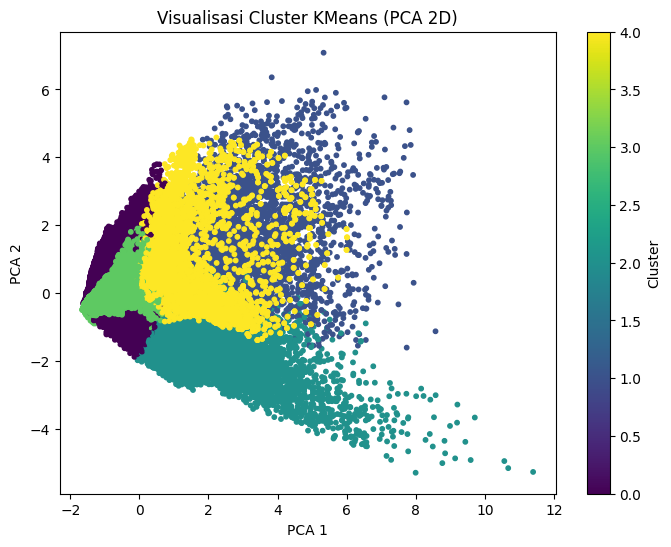

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduksi dimensi jadi 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_all)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', s=10)
plt.title('Visualisasi Cluster KMeans (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()

##Uji Model Klasifikasi - Input Manual

In [28]:
loaded_clf = joblib.load('best_model_classification.joblib')
loaded_scaler = joblib.load('scaler_classification.joblib')

categories = {
    0: "Good",
    1: "Moderate",
    2: "Unhealthy for Sensitive Groups",
    3: "Unhealthy",
    4: "Very Unhealthy",
    5: "Hazardous",
    6: "Beyond Scale"
}

print("\nMasukkan nilai untuk fitur-fitur berikut untuk memprediksi kategori AQI:")
try:
    no2 = float(input("NO2: "))
    so2 = float(input("SO2: "))
    o3 = float(input("O3: "))
    pm2_5 = float(input("PM2.5: "))
    pm10 = float(input("PM10: "))

    user_input = pd.DataFrame([{
        'NO2': no2,
        'SO2': so2,
        'O3': o3,
        'PM2.5': pm2_5,
        'PM10': pm10
    }])

    # Scaling input
    user_input_scaled = loaded_scaler.transform(user_input)

    predicted_label_num = loaded_clf.predict(user_input_scaled)[0]
    predicted_label_text = categories.get(predicted_label_num, "Unknown")

    print(f"\n🌫️ Kategori AQI yang diprediksi model: {predicted_label_text}")

except ValueError:
    print("Input tidak valid. Harap masukkan angka untuk setiap fitur.")


Masukkan nilai untuk fitur-fitur berikut untuk memprediksi kategori AQI:
NO2: 100
SO2: 200
O3: 120
PM2.5: 310
PM10: 90

🌫️ Kategori AQI yang diprediksi model: Unhealthy


##Uji Model Clustering KMeans - Input Manual

In [27]:
loaded_kmeans = joblib.load('kmeans_cluster.joblib')
loaded_scaler = joblib.load('scaler_classification.joblib')  # pakai scaler yang sama

print("\nMasukkan nilai untuk fitur-fitur berikut untuk menentukan cluster polusi:")

try:
    no2 = float(input("NO2: "))
    so2 = float(input("SO2: "))
    o3 = float(input("O3: "))
    pm2_5 = float(input("PM2.5: "))
    pm10 = float(input("PM10: "))

    # Buat DataFrame dari input pengguna
    user_input = pd.DataFrame([{
        'NO2': no2,
        'SO2': so2,
        'O3': o3,
        'PM2.5': pm2_5,
        'PM10': pm10
    }])

    # Standardisasi input
    user_input_scaled = loaded_scaler.transform(user_input)

    # Prediksi cluster
    predicted_cluster = loaded_kmeans.predict(user_input_scaled)[0]

    print(f"\n🌀 Data ini masuk ke **Cluster {predicted_cluster}**")

    # Opsional: berikan interpretasi makna cluster (bisa disesuaikan dari hasil cluster_summary)
    cluster_mean_desc = {
        0: "Rendah polusi (umumnya udara bersih)",
        1: "Sedang, polusi menengah dengan O3 cukup tinggi",
        2: "Polutan tinggi, terutama NO2 dan SO2",
        3: "PM2.5 dominan, udara agak tercemar",
        4: "Konsentrasi partikel tinggi, berpotensi berbahaya"
    }

    print(f"📊 Interpretasi: {cluster_mean_desc.get(predicted_cluster, 'Tidak diketahui')}")

except ValueError:
    print("Input tidak valid. Harap masukkan angka untuk setiap fitur.")


Masukkan nilai untuk fitur-fitur berikut untuk menentukan cluster polusi:
NO2: 80
SO2: 60
O3: 150
PM2.5: 200
PM10: 110

🌀 Data ini masuk ke **Cluster 4**
📊 Interpretasi: Konsentrasi partikel tinggi, berpotensi berbahaya


##Uji Model Klasifikasi - Real Time

In [29]:
try:
    loaded_clf_model = joblib.load("best_model_classification.joblib")
    loaded_scaler_model = joblib.load("scaler_classification.joblib")
    print("\n✅ Model klasifikasi berhasil dimuat.")
except FileNotFoundError:
    print("❌ Error: File best_model_classification.joblib tidak ditemukan.")
    loaded_clf_model = None
    loaded_scaler_model = None

def kategori_aqi_from_index(index):
    return categories.get(index, "Unknown")

latitude = -6.9222   # Bandung
longitude = 107.6069

API_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    'latitude': latitude,
    'longitude': longitude,
    'current': 'pm2_5,nitrogen_dioxide,ozone,pm10,sulphur_dioxide',
    'timezone': 'Asia/Bangkok'
}

print(f"\n🌤️ Memulai pengambilan data kualitas udara real-time untuk Bandung ({latitude}, {longitude})...\n")

start_time = time.time()
duration = 10  # lama pengambilan data (detik)
interval = 2   # jeda antar-pengambilan data (detik)

while time.time() - start_time < duration:
    try:
        response = requests.get(API_URL, params=params)
        response.raise_for_status()
        data = response.json()

        if 'current' in data:
            current_data = data['current']
            print(f"\n--- Data Terkini ({time.strftime('%H:%M:%S')}) ---")
            print(f"  NO2: {current_data.get('nitrogen_dioxide')} {data['current_units'].get('nitrogen_dioxide')}")
            print(f"  SO2: {current_data.get('sulphur_dioxide')} {data['current_units'].get('sulphur_dioxide')}")
            print(f"  O3: {current_data.get('ozone')} {data['current_units'].get('ozone')}")
            print(f"  PM2.5: {current_data.get('pm2_5')} {data['current_units'].get('pm2_5')}")
            print(f"  PM10: {current_data.get('pm10')} {data['current_units'].get('pm10')}")

            if loaded_clf_model is not None:
                # Siapkan input untuk model
                input_data = pd.DataFrame([{
                    'NO2': current_data.get('nitrogen_dioxide', 0),
                    'SO2': current_data.get('sulphur_dioxide', 0),
                    'O3': current_data.get('ozone', 0),
                    'PM2.5': current_data.get('pm2_5', 0),
                    'PM10': current_data.get('pm10', 0)
                }])

                # Scaling input
                input_scaled = loaded_scaler_model.transform(input_data)

                # Prediksi
                predicted_index = loaded_clf_model.predict(input_scaled)[0]
                predicted_label = kategori_aqi_from_index(predicted_index)

                print(f"\n  🔹 Prediksi Model: {predicted_label}")
            else:
                print("\n⚠️ Model belum dimuat, tidak dapat melakukan prediksi.")

        else:
            print("\nData 'current' tidak ditemukan dalam respons API.")
            print("Respons lengkap:", data)

    except requests.exceptions.RequestException as e:
        print(f"\n⚠️ Error API Open Meteo: {e}")
    except Exception as e:
        print(f"\n⚠️ Error tidak terduga: {e}")

    if time.time() - start_time < duration:
        time.sleep(interval)

print("\n✅ Uji model real-time selesai.")


✅ Model klasifikasi berhasil dimuat.

🌤️ Memulai pengambilan data kualitas udara real-time untuk Bandung (-6.9222, 107.6069)...


--- Data Terkini (10:18:35) ---
  NO2: 51.6 μg/m³
  SO2: 31.4 μg/m³
  O3: 57.0 μg/m³
  PM2.5: 68.2 μg/m³
  PM10: 68.5 μg/m³

  🔹 Prediksi Model: Moderate

--- Data Terkini (10:18:37) ---
  NO2: 51.6 μg/m³
  SO2: 31.4 μg/m³
  O3: 57.0 μg/m³
  PM2.5: 68.2 μg/m³
  PM10: 68.5 μg/m³

  🔹 Prediksi Model: Moderate

--- Data Terkini (10:18:39) ---
  NO2: 51.6 μg/m³
  SO2: 31.4 μg/m³
  O3: 57.0 μg/m³
  PM2.5: 68.2 μg/m³
  PM10: 68.5 μg/m³

  🔹 Prediksi Model: Moderate

--- Data Terkini (10:18:41) ---
  NO2: 51.6 μg/m³
  SO2: 31.4 μg/m³
  O3: 57.0 μg/m³
  PM2.5: 68.2 μg/m³
  PM10: 68.5 μg/m³

  🔹 Prediksi Model: Moderate

--- Data Terkini (10:18:43) ---
  NO2: 51.6 μg/m³
  SO2: 31.4 μg/m³
  O3: 57.0 μg/m³
  PM2.5: 68.2 μg/m³
  PM10: 68.5 μg/m³

  🔹 Prediksi Model: Moderate

✅ Uji model real-time selesai.


In [30]:
model_class = joblib.load('best_model_classification.joblib')
kmeans = joblib.load('kmeans_cluster.joblib')
scaler = joblib.load('scaler_classification.joblib')

# Contoh data real-time dari sensor
sensor_data = np.array([[22, 11, 83, 65, 71]])  # NO2, SO2, O3, PM2.5, PM10

# Standardisasi
sensor_scaled = scaler.transform(sensor_data)

# Prediksi klasifikasi & cluster
class_pred = model_class.predict(sensor_scaled)[0]
cluster_pred = kmeans.predict(sensor_scaled)[0]

# Mapping kategori AQI
aqi_categories = {
    0: "Baik (0–50)",
    1: "Sedang (51–100)",
    2: "Tidak Sehat (101–150)",
    3: "Sangat Tidak Sehat (151–200)",
    4: "Berbahaya (201–300)",
    5: "Ekstrem (301–500)",
    6: "Diluar Skala"
}

print(f"[REAL-TIME RESULT]")
print(f"Klasifikasi AQI  : {aqi_categories.get(class_pred, 'Tidak diketahui')}")
print(f"Cluster Polusi   : {cluster_pred}")

[REAL-TIME RESULT]
Klasifikasi AQI  : Sedang (51–100)
Cluster Polusi   : 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
